In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [3]:
experiment_folder = "experimentsLongitudinal" #"wei_experiments/experimentsLongitudinal/two_weeks/"
weeks = "preTreatment" #"preTreatment"#"three_weeks" "four_weeks"
experiment_name = "evaluation_densenet_3F_new" #"evaluation_seresnet_3F_nopCT_long" #"evaluation_7Wlr_5F" 
endpoint = "DFS"

In [4]:
path_to_evaluation_folder = "/scratch/hb-weeklyCT/"+experiment_folder+"/"+weeks+"/"+endpoint+"/"+experiment_name+"/best_f1_model_test_metrics.xlsx"

In [5]:
df = pd.read_excel(path_to_evaluation_folder)

In [6]:
df.groupby('Fold').mean()

,F1 Score Macro,Accuracy,AUC OVR,Precision Macro,Recall Macro
Fold,,,,,
1,0.641892,0.698113,0.638072,0.648246,0.638072
2,0.658065,0.716981,0.651961,0.670330,0.651961
3,0.564042,0.603774,0.568627,0.563636,0.568627
Avg Probability,0.610294,0.660377,0.610294,0.610294,0.610294
Majority Voting,0.597128,0.660377,0.594771,0.601754,0.594771


In [7]:
def read_split_file(path):

    with open(path, 'r') as inf:
        dict_from_file = eval(inf.read())
        
    return dict_from_file

In [17]:
split_file = "/scratch/hb-weeklyCT/experimentsLongitudinal/data_split/data_split_seqNum_"+str(2)+".txt"
split_data = read_split_file(split_file)

In [18]:
len(split_data["test"])

53

### Ensembling Test Results

In [8]:
%run plots.ipynb

In [9]:
test_list = ["UMCG-7987157", "UMCG-2145422", "UMCG-3857371", "UMCG-2194374", "UMCG-2087361", "UMCG-3184299", "UMCG-9743734", "UMCG-2264907", "UMCG-1320820", "UMCG-2130970", "UMCG-4223355", "UMCG-2176162", "UMCG-0298536", "UMCG-3220326", "UMCG-9280356", "UMCG-2125979", "UMCG-9946201", "UMCG-3761226", "UMCG-2190498", "UMCG-2075963", "UMCG-2102599", "UMCG-2002365", "UMCG-2690513", "UMCG-4391448", "UMCG-0345451", "UMCG-5896858", "UMCG-4160083", "UMCG-4134310", "UMCG-1051551", "UMCG-0838551", "UMCG-9899837", "UMCG-2241472", "UMCG-2781091", "UMCG-7876032", "UMCG-2159400", "UMCG-8716940", "UMCG-1737477", "UMCG-9146365", "UMCG-6754277", "UMCG-2222276", "UMCG-1097433", "UMCG-2291679", "UMCG-4939497", "UMCG-9715913", "UMCG-0598217", "UMCG-0412861", "UMCG-9007625", "UMCG-2278873", "UMCG-0861452", "UMCG-4224256", "UMCG-2110034", "UMCG-3979255", "UMCG-2724732"]

In [10]:
#pd.DataFrame(test_list).to_excel("/scratch/hb-weeklyCT/experimentsLongitudinal/data_split/test_patients.xlsx")

In [11]:
outcome_file = "/scratch/hb-weeklyCT/experimentsLongitudinal/outcomes.xlsx"
outcomes_ = pd.read_excel(outcome_file)

outcomes_.columns

Index(['PatientID', 'two_weeks', 'three_weeks', 'four_weeks', 'OS', 'DFS',
       'LRC'],
      dtype='object')

In [12]:
outcome_file = "/scratch/hb-weeklyCT/experimentsLongitudinal/outcomes.xlsx"
outcomes_ = pd.read_excel(outcome_file)

majority_labels = list()
for id_ in test_list:
    outcome = outcomes_.loc[outcomes_['PatientID'] == id_, 'DFS'].values
    if outcome.size > 0:
        majority_labels.append(outcome[0])
    else:
        majority_labels.append(None) 

In [77]:
experiment_folder = "two_weeks" #"wei_experiments/experimentsLongitudinal/two_weeks/"

experiment_type = "multi_TCN"

endpoint = "DFS"

save_path = "/scratch/hb-weeklyCT/experimentsLongitudinal/save_plots/"+experiment_type+"_"+experiment_folder+".jpeg"

In [43]:
#old runs DO NOT CHANGE
model_ = "seresnet"

experiment_names = {
                "single" : ["evaluation_"+model_+"_3F_new"], #,"evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                "multi_selfAtt" : ["evaluation_"+model_+"_3F_new"], #"evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                "multi_TCN" : ["evaluation_"+model_+"_3F_TCN"], #,"evaluation_resnet_3F_TCN","evaluation_seresnet_3F_TCN"],
                "multi_selfAtt_nopCT" : ["evaluation_"+model_+"_3F_nopCT"], #,"evaluation_resnet_3F_nopCT","evaluation_seresnet_3F_nopCT"],
                "multi_TCN_nopCT" : ["evaluation_"+model_+"_3F_TCN_nopCT"], #,"evaluation_resnet_3F_TCN_nopCT","evaluation_seresnet_3F_TCN_nopCT"]
                    }

In [74]:
'''
experiment_names = {
                    "single" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_selfAtt" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_TCN" : ["evaluation_densenet_3F_TCN_long","evaluation_resnet_3F_TCN_long","evaluation_seresnet_3F_TCN_long"],
                    "multi_selfAtt_nopCT" : ["evaluation_densenet_3F_nopCT_long","evaluation_resnet_3F_nopCT_long","evaluation_seresnet_3F_nopCT_long"],
                    "multi_TCN_nopCT" : ["evaluation_densenet_3F_TCN_nopCT_long","evaluation_resnet_3F_TCN_nopCT_long","evaluation_seresnet_3F_TCN_nopCT_long"]
                    }
'''

In [78]:
#old runs DO NOT CHANGE
experiment_names = {
                    "single" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_selfAtt" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_TCN" : ["evaluation_densenet_3F_TCN","evaluation_resnet_3F_TCN","evaluation_seresnet_3F_TCN"],
                    "multi_selfAtt_nopCT" : ["evaluation_densenet_3F_nopCT","evaluation_resnet_3F_nopCT","evaluation_seresnet_3F_nopCT"],
                    "multi_TCN_nopCT" : ["evaluation_densenet_3F_TCN_nopCT","evaluation_resnet_3F_TCN_nopCT","evaluation_seresnet_3F_TCN_nopCT"]
                    }

In [16]:
def test_ensemble_results(exp_name, save_path, save_cal, bins):    
    f1s = list()
    auc = list()
    accurac = list()
    metrics = list()
    dataframe = []

    experiment_name = experiment_names[exp_name]
    print(exp_name)

    for i in experiment_name: 

        name_file = "probabilities.csv"
        endpoint = "DFS"

        path_to_evaluation_folder = "/scratch/hb-weeklyCT/experimentsLongitudinal/"+experiment_folder+"/"+endpoint+"/"+ i +"/"+name_file

        df = pd.read_csv(path_to_evaluation_folder,header=None)
        dataframe.append(df)
    
    combined_df = pd.concat(dataframe, axis=1, ignore_index=True)
    
    majority_outputs = (combined_df > 0.5).astype(int)

    final_labels = list()
    final_outputs = list()
    final_avg_output = list()
    save_avg = list()

    prob = list()

    for i in range(0,combined_df.shape[0]):

        final_labels.append(majority_labels[i])  

        final_outputs.append(np.bincount(majority_outputs.loc[i].values).argmax())  

        avg = np.mean(combined_df.loc[i].values)
        save_avg.append(avg)
        
        bin_ = 0 if avg<0.5 else 1
        final_avg_output.append(bin_)
        prob.append(avg)

    majority_metrics = calculate_metrics(final_labels, prob)
    majority_metrics['Fold'] = 'Majority Voting'
    metrics.append(majority_metrics)    

    avg_prob_metrics = calculate_metrics(final_labels, prob)
    avg_prob_metrics['Fold'] = 'Avg Probability'
    metrics.append(avg_prob_metrics)    
    
    calibration_plot(final_labels,save_avg, save_path, save_cal, bins) #put 5
    
    df = pd.DataFrame(metrics)

    print(df[df["Fold"]=="Avg Probability"])
    
    print(" ")
    print("===========")
    print(" ")

In [30]:
#bins of 15 for TCN and of 5 for Self Attention

Results for w4
 
single


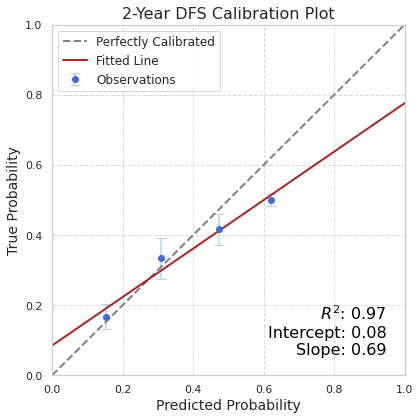

   F1 Score Macro  Accuracy   AUC OVR  Precision Macro  Recall Macro  \
1        0.528025  0.679245  0.624183         0.601064      0.546569   

              Fold  
1  Avg Probability  
 
 


In [84]:
experiment_folder = "w4" 

for exp_name in ["single"]: #, "multi_selfAtt_nopCT" , "multi_selfAtt", "multi_TCN", "multi_TCN_nopCT"]:"multi_selfAtt"
    
    save_path = "/scratch/hb-weeklyCT/experimentsLongitudinal/save_plots/new_plots/"+exp_name+"_"+experiment_folder+".jpeg"
    
    print("Results for " + experiment_folder)
    print(" ")
    test_ensemble_results(exp_name,save_path, save_cal=True, bins = 5)

Results for w4
 
single


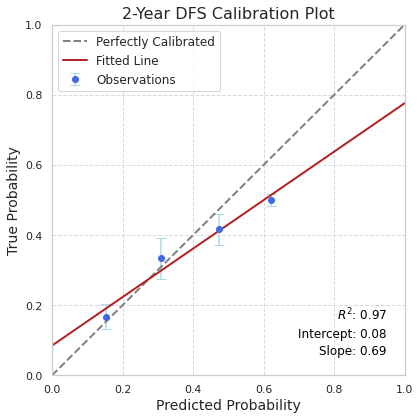

   F1 Score Macro  Accuracy   AUC OVR  Precision Macro  Recall Macro  \
1        0.528025  0.679245  0.546569         0.601064      0.546569   

              Fold  
1  Avg Probability  
 
 


In [17]:
experiment_folder = "w4" 

for exp_name in ["single"]: #, "multi_TCN", "multi_TCN_nopCT"]:"multi_selfAtt"
    
    save_path = "/scratch/hb-weeklyCT/experimentsLongitudinal/save_plots/"+exp_name+"_"+experiment_folder+".jpeg"
    
    print("Results for " + experiment_folder)
    print(" ")
    test_ensemble_results(exp_name,save_path)

In [9]:
experiment_names = {
                    "best_single" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_selfAtt_best" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_TCN_best" : ["evaluation_densenet_3F_TCN","evaluation_resnet_3F_TCN","evaluation_seresnet_3F_TCN"],
                    "multi_TCN_nopCT_test" : ["evaluation_densenet_3F_TCN_nopCT","evaluation_resnet_3F_TCN_nopCT","evaluation_seresnet_3F_TCN_nopCT"]
                    }

In [19]:
experiment_names = {
                    "best_singleTP1_densenet" : ["evaluation_densenet_3F_new",],
                    "best_singleTP1_seresnet" : ["evaluation_seresnet_3F_new",],
                    }

Results for preTreatment
 
best_singleTP1_seresnet


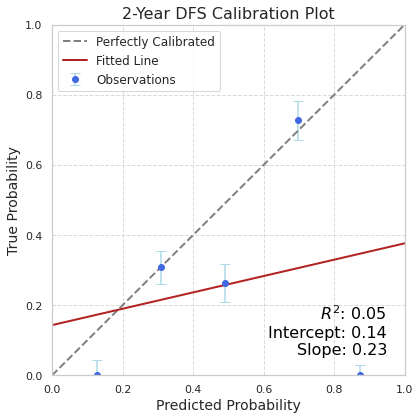

   F1 Score Macro  Accuracy   AUC OVR  Precision Macro  Recall Macro  \
1        0.736318  0.754717  0.757353         0.730938      0.757353   

              Fold  
1  Avg Probability  
 
 


In [21]:
experiment_folder = "preTreatment" 

for exp_name in ["best_singleTP1_seresnet"]: #, "multi_TCN", "multi_TCN_nopCT"]:"multi_selfAtt"
    
    save_path = "/scratch/hb-weeklyCT/experimentsLongitudinal/save_plots/"+exp_name+"_"+experiment_folder+".jpeg"
    print("Results for " + experiment_folder)
    print(" ")
    test_ensemble_results(exp_name,save_path)

In [118]:
import pandas as pd
import numpy as np
import scipy.stats

# AUC comparison adapted from
# https://github.com/Netflix/vmaf/
def compute_midrank(x):
    """Computes midranks.
    Args:
       x - a 1D numpy array
    Returns:
       array of midranks
    """
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    # Note(kazeevn) +1 is due to Python using 0-based indexing
    # instead of 1-based in the AUC formula in the paper
    T2[J] = T + 1
    return T2


def fastDeLong(predictions_sorted_transposed, label_1_count):
    """
    The fast version of DeLong's method for computing the covariance of
    unadjusted AUC.
    Args:
       predictions_sorted_transposed: a 2D numpy.array[n_classifiers, n_examples]
          sorted such as the examples with label "1" are first
    Returns:
       (AUC value, DeLong covariance)
    Reference:
     @article{sun2014fast,
       title={Fast Implementation of DeLong's Algorithm for
              Comparing the Areas Under Correlated Receiver Operating Characteristic Curves},
       author={Xu Sun and Weichao Xu},
       journal={IEEE Signal Processing Letters},
       volume={21},
       number={11},
       pages={1389--1393},
       year={2014},
       publisher={IEEE}
     }
    """
    # Short variables are named as they are in the paper
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov


def calc_pvalue(aucs, sigma):
    """Computes log(10) of p-values.
    Args:
       aucs: 1D array of AUCs
       sigma: AUC DeLong covariances
    Returns:
       log10(pvalue)
    """
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return np.log10(2) + scipy.stats.norm.logsf(z, loc=0, scale=1) / np.log(10)

def calc_pvalue(aucs, sigma):
    """Computes actual p-value"""
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    pval = 2 * scipy.stats.norm.sf(z)
    return pval

def compute_ground_truth_statistics(ground_truth):
    assert np.array_equal(np.unique(ground_truth), [0, 1])
    order = (-ground_truth).argsort()
    label_1_count = int(ground_truth.sum())
    return order, label_1_count


def delong_roc_variance(ground_truth, predictions):
    """
    Computes ROC AUC variance for a single set of predictions
    Args:
       ground_truth: np.array of 0 and 1
       predictions: np.array of floats of the probability of being class 1
    """
    order, label_1_count = compute_ground_truth_statistics(ground_truth)
    predictions_sorted_transposed = predictions[np.newaxis, order]
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    assert len(aucs) == 1, "There is a bug in the code, please forward this to the developers"
    return aucs[0], delongcov


def delong_roc_test(ground_truth, predictions_one, predictions_two):
    """
    Computes log(p-value) for hypothesis that two ROC AUCs are different
    Args:
       ground_truth: np.array of 0 and 1
       predictions_one: predictions of the first model,
          np.array of floats of the probability of being class 1
       predictions_two: predictions of the second model,
          np.array of floats of the probability of being class 1
    """
    order, label_1_count = compute_ground_truth_statistics(ground_truth)
    predictions_sorted_transposed = np.vstack((predictions_one, predictions_two))[:, order]
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    return calc_pvalue(aucs, delongcov)

### Statistical Tests:

In [119]:
experiment_names = {
                    "single" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_selfAtt" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_TCN" : ["evaluation_densenet_3F_TCN","evaluation_resnet_3F_TCN","evaluation_seresnet_3F_TCN"],
                    "multi_selfAtt_nopCT" : ["evaluation_densenet_3F_nopCT","evaluation_resnet_3F_nopCT","evaluation_seresnet_3F_nopCT"],
                    "multi_TCN_nopCT" : ["evaluation_densenet_3F_TCN_nopCT","evaluation_resnet_3F_TCN_nopCT","evaluation_seresnet_3F_TCN_nopCT"]
                    }

In [120]:
def per_time_point_calculation(experiment_folder):    
    
    f1s = list()
    auc = list()
    accurac = list()
    metrics = list()
    dataframe = []

    for i in experiment_name: 

        name_file = "probabilities.csv"
        endpoint = "DFS"

        path_to_evaluation_folder = "/scratch/hb-weeklyCT/experimentsLongitudinal/"+experiment_folder+"/"+endpoint+"/"+ i +"/"+name_file

        df = pd.read_csv(path_to_evaluation_folder,header=None)

        dataframe.append(df)

    combined_df = pd.concat(dataframe, axis=1, ignore_index=True)
    majority_outputs = (combined_df > 0.5).astype(int)

    final_labels = list()
    final_outputs = list()
    final_avg_output = list()
    save_avg = list()

    prob = list()

    for i in range(0,combined_df.shape[0]):

        final_labels.append(majority_labels[i])  

        final_outputs.append(np.bincount(majority_outputs.loc[i].values).argmax())  

        avg = np.mean(combined_df.loc[i].values)
        save_avg.append(avg)
        bin_ = 0 if avg<0.5 else 1
        final_avg_output.append(bin_)
        prob.append(avg)
        
    return final_labels, final_avg_output

In [121]:
experiment_folders = ["preTreatment","w1","w2","w3","w4"]
pred = list()
for exp_fold in experiment_folders:
    
    lab , pred_ = per_time_point_calculation(exp_fold)
    pred.append(pred_)

In [122]:
f1_overview = [calculate_metrics(lab, j)['F1 Score Macro'] for j in pred]
accuracy_overview = [calculate_metrics(lab, j)['Accuracy'] for j in pred]
auc_overview = [calculate_metrics(lab, j)['AUC OVR'] for j in pred]

In [1]:
!pip install scipy numpy scikit-learn
!pip install git+https://github.com/yandexdataschool/roc_comparison.git

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/yandexdataschool/roc_comparison.git to /tmp/pip-req-build-b00860__
  Running command git clone --filter=blob:none --quiet https://github.com/yandexdataschool/roc_comparison.git /tmp/pip-req-build-b00860__
  Resolved https://github.com/yandexdataschool/roc_comparison.git to commit 44fcd23c998b39f30440d833a0820f1c7e6d8bc7
ERROR: git+https://github.com/yandexdataschool/roc_comparison.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from sklearn.metrics import roc_auc_score
from roc_comparison import delong_roc_test

# y_true: ground truth binary labels (e.g., 0 = negative, 1 = positive)
# y_pred_1, y_pred_2: predicted probabilities from two models

#models_metrics = []
#for y_pred in y_preds:
#    accuracy, f1_macro, auc = calculate_metrics(y_true, y_pred)
#    models_metrics.append((accuracy, f1_macro, auc))
    
y_pred_1 = y_preds[0]
y_pred_2 = y_preds[1]
# Example usage:
p_value = delong_roc_test(y_true, y_pred_1, y_pred_2)

print("P-value:", p_value)

In [ ]:
models_metrics = []
for y_pred in y_preds:
    accuracy, f1_macro, auc = calculate_metrics(y_true, y_pred)
    models_metrics.append((accuracy, f1_macro, auc))

# Initialize list to store results
pairwise_results = []

# Perform pairwise Wilcoxon signed-rank test for performance metrics
for (i, metrics1), (j, metrics2) in combinations(enumerate(models_metrics), 2):
    stat, p = wilcoxon(metrics1, metrics2)
    pairwise_results.append((i, j, stat, p))

# Print pairwise results
for (i, j, stat, p) in pairwise_results:
    print(f"Comparison between model {i+1} and model {j+1}:")
    print(f"  Wilcoxon stat: {stat}, p-value: {p:.4f}")
    if p < 0.05:
        print("  There is a significant difference in performance.")
    else:
        print("  There is no significant difference in performance.")
    print()

In [55]:
from scipy.stats import wilcoxon
from itertools import combinations

# Initialize list to store results
pairwise_results = []

# Perform pairwise Wilcoxon signed-rank test for instance-level predictions
for (i, y_pred1), (j, y_pred2) in combinations(enumerate(y_preds), 2):
    diffs1 = y_pred1 == y_true
    diffs2 = y_pred2 == y_true
    stat, p = wilcoxon(diffs1*1, diffs2*1)
    pairwise_results.append((i, j, stat, p))

# Print initial pairwise results
for (i, j, stat, p) in pairwise_results:
    print(f"Comparison between model {i} and model {j}:")
    print(f"  Wilcoxon stat: {stat}, original p-value: {p}")

Comparison between model 0 and model 1:
  Wilcoxon stat: 52.5, original p-value: 1.0
Comparison between model 0 and model 2:
  Wilcoxon stat: 76.0, original p-value: 0.6373518882339371
Comparison between model 0 and model 3:
  Wilcoxon stat: 45.0, original p-value: 0.5929800980174267
Comparison between model 0 and model 4:
  Wilcoxon stat: 59.5, original p-value: 0.6170750774519738
Comparison between model 1 and model 2:
  Wilcoxon stat: 32.5, original p-value: 0.5637028616507731
Comparison between model 1 and model 3:
  Wilcoxon stat: 59.5, original p-value: 0.6170750774519738
Comparison between model 1 and model 4:
  Wilcoxon stat: 45.0, original p-value: 0.5929800980174267
Comparison between model 2 and model 3:
  Wilcoxon stat: 52.5, original p-value: 1.0
Comparison between model 2 and model 4:
  Wilcoxon stat: 39.0, original p-value: 1.0
Comparison between model 3 and model 4:
  Wilcoxon stat: 10.5, original p-value: 1.0


/home3/p302386/.local/lib/python3.10/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


In [56]:
from statsmodels.stats.multitest import multipletests

# Extract p-values from the pairwise results
p_values = [result[3] for result in pairwise_results]

# Apply Holm-Bonferroni correction
rejected, corrected_pvals, _, _ = multipletests(p_values, alpha=0.05, method='holm')

# Apply Benjamini-Hochberg correction
rejected_bh, corrected_pvals_bh, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print results
for (i, j, stat, p), reject_holm, reject_bh, corrected_p_holm, corrected_p_bh in zip(pairwise_results, rejected, rejected_bh, corrected_pvals, corrected_pvals_bh):
    print(f"Comparison between model {i} and model {j}:")
    print(f"  Wilcoxon stat: {stat}, original p-value: {p}")
    print(f"  Holm-Bonferroni corrected p-value: {corrected_p_holm}, reject: {reject_holm}")
    print(f"  Benjamini-Hochberg corrected p-value: {corrected_p_bh}, reject: {reject_bh}")


Comparison between model 0 and model 1:
  Wilcoxon stat: 52.5, original p-value: 1.0
  Holm-Bonferroni corrected p-value: 1.0, reject: False
  Benjamini-Hochberg corrected p-value: 1.0, reject: False
Comparison between model 0 and model 2:
  Wilcoxon stat: 76.0, original p-value: 0.6373518882339371
  Holm-Bonferroni corrected p-value: 1.0, reject: False
  Benjamini-Hochberg corrected p-value: 1.0, reject: False
Comparison between model 0 and model 3:
  Wilcoxon stat: 45.0, original p-value: 0.5929800980174267
  Holm-Bonferroni corrected p-value: 1.0, reject: False
  Benjamini-Hochberg corrected p-value: 1.0, reject: False
Comparison between model 0 and model 4:
  Wilcoxon stat: 59.5, original p-value: 0.6170750774519738
  Holm-Bonferroni corrected p-value: 1.0, reject: False
  Benjamini-Hochberg corrected p-value: 1.0, reject: False
Comparison between model 1 and model 2:
  Wilcoxon stat: 32.5, original p-value: 0.5637028616507731
  Holm-Bonferroni corrected p-value: 1.0, reject: False

### Statistical Tests revision:

In [179]:
experiment_names = {
                    "single" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_selfAtt" : ["evaluation_densenet_3F_new","evaluation_resnet_3F_new","evaluation_seresnet_3F_new"],
                    "multi_TCN" : ["evaluation_densenet_3F_TCN","evaluation_resnet_3F_TCN","evaluation_seresnet_3F_TCN"],
                    "multi_selfAtt_nopCT" : ["evaluation_densenet_3F_nopCT","evaluation_resnet_3F_nopCT","evaluation_seresnet_3F_nopCT"],
                    "multi_TCN_nopCT" : ["evaluation_densenet_3F_TCN_nopCT","evaluation_resnet_3F_TCN_nopCT","evaluation_seresnet_3F_TCN_nopCT"]
                    }

In [180]:
def per_time_point_calculation(experiment_folder, exp_name):    
    
    f1s = list()
    auc = list()
    accurac = list()
    metrics = list()
    dataframe = []

    for i in exp_name: 

        name_file = "probabilities.csv"
        endpoint = "DFS"

        path_to_evaluation_folder = "/scratch/hb-weeklyCT/experimentsLongitudinal/"+experiment_folder+"/"+endpoint+"/"+ i +"/"+name_file

        df = pd.read_csv(path_to_evaluation_folder,header=None)

        dataframe.append(df)

    combined_df = pd.concat(dataframe, axis=1, ignore_index=True)
    majority_outputs = (combined_df > 0.5).astype(int)

    final_labels = list()
    final_outputs = list()
    final_avg_output = list()
    save_avg = list()

    prob = list()

    for i in range(0,combined_df.shape[0]):

        final_labels.append(majority_labels[i])  

        final_outputs.append(np.bincount(majority_outputs.loc[i].values).argmax())  

        avg = np.mean(combined_df.loc[i].values)
        save_avg.append(avg)
        bin_ = 0 if avg<0.5 else 1
        final_avg_output.append(bin_)
        prob.append(avg)
        
    return final_labels, save_avg, final_avg_output

In [181]:
experiment_folders_one = ["preTreatment","w1","w2","w3","w4"]
pred = list()
pred_probs = list()
nam = list()
for exp_fold in experiment_folders_one:
    
    lab , pred_prob, pred_ = per_time_point_calculation(exp_fold, experiment_names["single"])
    nam.append(exp_fold)
    pred.append(pred_)
    pred_probs.append(pred_prob)

In [182]:
experiment_folders_more = ["two_weeks","three_weeks","four_weeks"]
for exp_fold in experiment_folders_more:
    for type_ in ["multi_selfAtt_nopCT","multi_selfAtt","multi_TCN_nopCT","multi_TCN"]:
        lab , pred_prob, pred_ = per_time_point_calculation(exp_fold, experiment_names[type_])
        nam.append(exp_fold+"_"+type_)
        pred.append(pred_)
        pred_probs.append(pred_prob)

In [183]:
f1_overview = [calculate_metrics(lab, j)['F1 Score Macro'] for j in pred]
accuracy_overview = [calculate_metrics(lab, j)['Accuracy'] for j in pred]
auc_overview = [calculate_metrics(lab, j)['AUC OVR'] for j in pred_probs]

In [184]:
list(zip(auc_overview, nam))

[(0.7401960784313726, 'preTreatment'),
 (0.7189542483660131, 'w1'),
 (0.6977124183006536, 'w2'),
 (0.6748366013071896, 'w3'),
 (0.6241830065359477, 'w4'),
 (0.6666666666666667, 'two_weeks_multi_selfAtt_nopCT'),
 (0.6143790849673203, 'two_weeks_multi_selfAtt'),
 (0.6094771241830066, 'two_weeks_multi_TCN_nopCT'),
 (0.6307189542483661, 'two_weeks_multi_TCN'),
 (0.6862745098039216, 'three_weeks_multi_selfAtt_nopCT'),
 (0.6486928104575163, 'three_weeks_multi_selfAtt'),
 (0.6584967320261438, 'three_weeks_multi_TCN_nopCT'),
 (0.6176470588235294, 'three_weeks_multi_TCN'),
 (0.6862745098039215, 'four_weeks_multi_selfAtt_nopCT'),
 (0.7156862745098039, 'four_weeks_multi_selfAtt'),
 (0.5294117647058824, 'four_weeks_multi_TCN_nopCT'),
 (0.6764705882352942, 'four_weeks_multi_TCN')]

In [185]:
alpha = 0.05
n_comparisons = len(pred_probs) - 1
corrected_alpha = alpha / n_comparisons

print(f"Bonferroni-corrected alpha: {corrected_alpha:.5f}\n")

for i in range(1, len(pred_probs)):
    p_value = delong_roc_test(np.array(lab), pred_probs[0], pred_probs[i])[0][0]
    significance = "SIGNIFICANT" if p_value < corrected_alpha else "not significant"
    print(f"Compared to: {nam[i]}")
    print(f"p-value: {p_value:.4g} ({significance})\n")

Bonferroni-corrected alpha: 0.00313

Compared to: w1
p-value: 0.7424 (not significant)

Compared to: w2
p-value: 0.5204 (not significant)

Compared to: w3
p-value: 0.3831 (not significant)

Compared to: w4
p-value: 0.09268 (not significant)

Compared to: two_weeks_multi_selfAtt_nopCT
p-value: 0.2317 (not significant)

Compared to: two_weeks_multi_selfAtt
p-value: 0.07384 (not significant)

Compared to: two_weeks_multi_TCN_nopCT
p-value: 0.03703 (not significant)

Compared to: two_weeks_multi_TCN
p-value: 0.0483 (not significant)

Compared to: three_weeks_multi_selfAtt_nopCT
p-value: 0.289 (not significant)

Compared to: three_weeks_multi_selfAtt
p-value: 0.1108 (not significant)

Compared to: three_weeks_multi_TCN_nopCT
p-value: 0.367 (not significant)

Compared to: three_weeks_multi_TCN
p-value: 0.02061 (not significant)

Compared to: four_weeks_multi_selfAtt_nopCT
p-value: 0.4405 (not significant)

Compared to: four_weeks_multi_selfAtt
p-value: 0.7477 (not significant)

Compared to: 

In [186]:
from itertools import combinations

alpha = 0.05
model_indices = range(len(pred_probs))
pairs = list(combinations(model_indices, 2))
corrected_alpha = alpha / len(pairs)

print(f"Number of comparisons: {len(pairs)}")
print(f"Bonferroni-corrected alpha: {corrected_alpha:.5f}\n")

for i, j in pairs:
    log10_p = delong_roc_test(np.array(lab), pred_probs[i], pred_probs[j])[0][0]
    p_value = log10_p
    significance = "SIGNIFICANT" if p_value < alpha else "not significant"
    print(f"{nam[i]} vs {nam[j]} → p-value: {p_value:.4g} ({significance})")

Number of comparisons: 136
Bonferroni-corrected alpha: 0.00037

preTreatment vs w1 → p-value: 0.7424 (not significant)
preTreatment vs w2 → p-value: 0.5204 (not significant)
preTreatment vs w3 → p-value: 0.3831 (not significant)
preTreatment vs w4 → p-value: 0.09268 (not significant)
preTreatment vs two_weeks_multi_selfAtt_nopCT → p-value: 0.2317 (not significant)
preTreatment vs two_weeks_multi_selfAtt → p-value: 0.07384 (not significant)
preTreatment vs two_weeks_multi_TCN_nopCT → p-value: 0.03703 (SIGNIFICANT)
preTreatment vs two_weeks_multi_TCN → p-value: 0.0483 (SIGNIFICANT)
preTreatment vs three_weeks_multi_selfAtt_nopCT → p-value: 0.289 (not significant)
preTreatment vs three_weeks_multi_selfAtt → p-value: 0.1108 (not significant)
preTreatment vs three_weeks_multi_TCN_nopCT → p-value: 0.367 (not significant)
preTreatment vs three_weeks_multi_TCN → p-value: 0.02061 (SIGNIFICANT)
preTreatment vs four_weeks_multi_selfAtt_nopCT → p-value: 0.4405 (not significant)
preTreatment vs fou

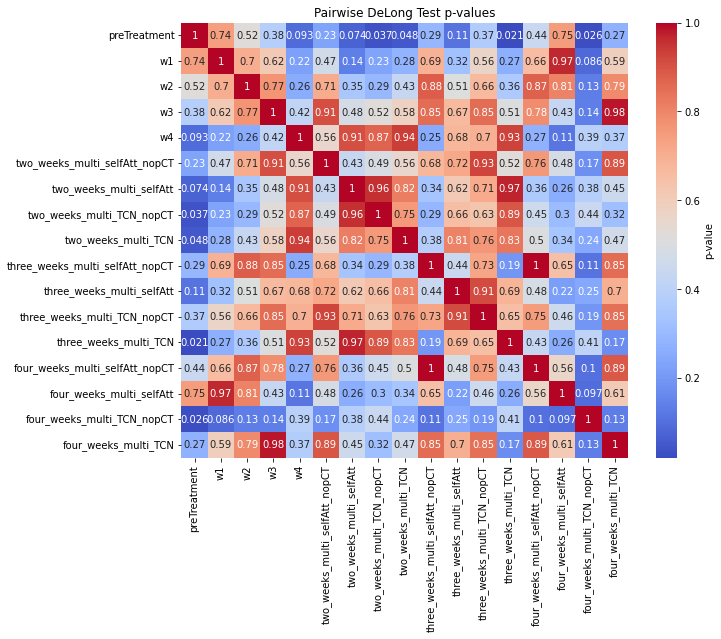

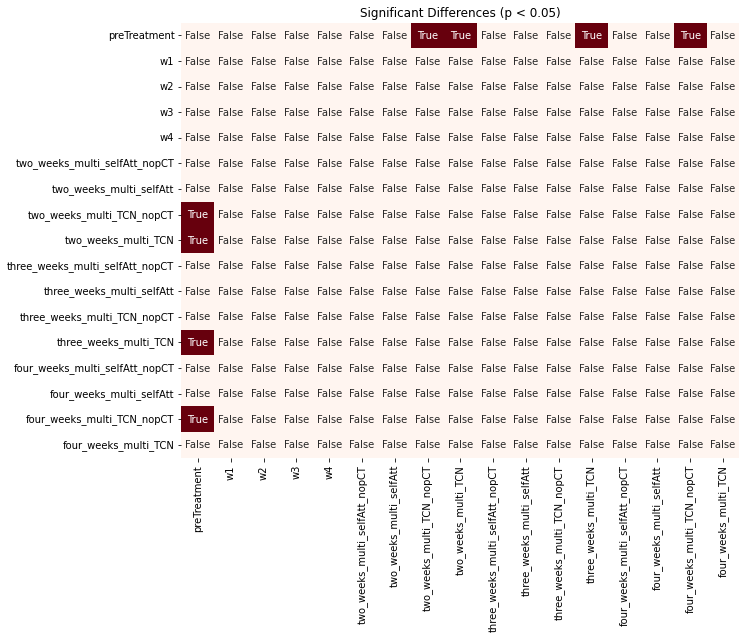

In [187]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations

# Setup
n_models = len(pred_probs)
names = nam  # your model names list
pval_matrix = np.ones((n_models, n_models))  # initialize with 1s
alpha = 0.05
pairs = list(combinations(range(n_models), 2))
corrected_alpha = alpha / len(pairs)

# Fill upper triangle with p-values
for i, j in pairs:
    log10_p = delong_roc_test(np.array(lab), pred_probs[i], pred_probs[j])[0][0]
    p_value = log10_p
    pval_matrix[i, j] = p_value
    pval_matrix[j, i] = p_value  # mirror for symmetry

# Convert to DataFrame for heatmap
df_pvals = pd.DataFrame(pval_matrix, index=names, columns=names)

# Plot full p-value heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_pvals, annot=True, fmt=".2g", cmap="coolwarm", cbar_kws={'label': 'p-value'})
plt.title("Pairwise DeLong Test p-values")
plt.show()

# Plot binary significance heatmap
sig_mask = df_pvals < alpha#corrected_alpha
plt.figure(figsize=(10, 8))
sns.heatmap(sig_mask, annot=sig_mask, fmt="", cmap="Reds", cbar=False)
plt.title(f"Significant Differences (p < {alpha:.3g})")
plt.show()

In [157]:
import pandas as pd
import numpy as np
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Function for Benjamini-Yekutieli (BY) correction
def benjamini_yekutieli(pvals):
    """Apply the Benjamini-Yekutieli correction to p-values."""
    pvals_sorted = np.sort(pvals)
    m = len(pvals)  # Number of comparisons
    cf_m = np.sum(1.0 / np.arange(1, m + 1))  # Correction factor for BY method
    corrected_pvals = pvals_sorted * m / cf_m  # Apply the correction factor

    # Ensure that corrected p-values do not exceed 1
    corrected_pvals = np.minimum(corrected_pvals, 1)
    
    # Reorder the corrected p-values to match the original order
    idx_sorted = np.argsort(pvals)
    corrected_pvals_reordered = corrected_pvals[np.argsort(idx_sorted)]
    return corrected_pvals_reordered

# Store results
results = []
names = nam  # Assuming `nam` is a list of model names
model_indices = range(len(pred_probs))

pairs = list(combinations(model_indices, 2))
uncorrected_pvals = []

# Step 1: Compute all p-values
for i, j in pairs:
    log10_p = delong_roc_test(np.array(lab), pred_probs[i], pred_probs[j])[0][0]
    p = log10_p  # Convert log10(p) to actual p-value
    uncorrected_pvals.append(p)
    results.append((names[i], names[j], p))

# Step 2: Apply Holm correction using multipletests
uncorrected_pvals = np.array(uncorrected_pvals)
_, pvals_holm, _, _ = multipletests(uncorrected_pvals, method='holm')

# Step 3: Apply Benjamini-Yekutieli correction (custom function)
pvals_bh_by = benjamini_yekutieli(uncorrected_pvals)

# Step 4: Create DataFrame
df = pd.DataFrame(results, columns=["Model 1", "Model 2", "Uncorrected p"])
df["Holm-corrected p"] = pvals_holm
df["FDR-BY-corrected p"] = pvals_bh_by
df["Significant (Holm)"] = df["Holm-corrected p"] < 0.05
df["Significant (FDR-BY)"] = df["FDR-BY-corrected p"] < 0.05

# Step 5: Show table
df

,Model 1,Model 2,Uncorrected p,Holm-corrected p,FDR-BY-corrected p,Significant (Holm),Significant (FDR-BY)
0,preTreatment,w1,0.742435,1.0,1.0,False,False
1,preTreatment,w2,0.520447,1.0,1.0,False,False
2,preTreatment,w3,0.383093,1.0,1.0,False,False
3,preTreatment,w4,0.092681,1.0,1.0,False,False
4,preTreatment,two_weeks_multi_selfAtt_nopCT,0.231732,1.0,1.0,False,False
...,...,...,...,...,...,...,...
131,four_weeks_multi_selfAtt_nopCT,four_weeks_multi_TCN_nopCT,0.104630,1.0,1.0,False,False
132,four_weeks_multi_selfAtt_nopCT,four_weeks_multi_TCN,0.891276,1.0,1.0,False,False
133,four_weeks_multi_selfAtt,four_weeks_multi_TCN_nopCT,0.096603,1.0,1.0,False,False
134,four_weeks_multi_selfAtt,four_weeks_multi_TCN,0.612359,1.0,1.0,False,False


In [133]:
import numpy as np
import pandas as pd
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Store results
results = []
names = nam
model_indices = range(len(pred_probs))

pairs = list(combinations(model_indices, 2))
uncorrected_pvals = []

# Step 1: Compute all p-values
for i, j in pairs:
    log10_p = delong_roc_test(np.array(lab), pred_probs[i], pred_probs[j])[0][0]
    p = log10_p
    uncorrected_pvals.append(p)
    results.append((names[i], names[j], p))

# Step 2: Apply Holm and Benjamini-Hochberg corrections
uncorrected_pvals = np.array(uncorrected_pvals)
_, pvals_holm, _, _ = multipletests(uncorrected_pvals, method='holm')
_, pvals_bh, _, _ = multipletests(uncorrected_pvals, method='fdr_bh')

# Step 3: Create DataFrame
df = pd.DataFrame(results, columns=["Model 1", "Model 2", "Uncorrected p"])
df["Holm-corrected p"] = pvals_holm
df["FDR-corrected p (BH)"] = pvals_bh
df["Significant (Holm)"] = df["Holm-corrected p"] < 0.05
df["Significant (FDR)"] = df["FDR-corrected p (BH)"] < 0.05

# Step 4: Show table
df

,Model 1,Model 2,Uncorrected p,Holm-corrected p,FDR-corrected p (BH),Significant (Holm),Significant (FDR)
0,preTreatment,w1,0.742435,1.0,0.958829,False,False
1,preTreatment,w2,0.520447,1.0,0.943744,False,False
2,preTreatment,w3,0.383093,1.0,0.943744,False,False
3,preTreatment,w4,0.092681,1.0,0.943744,False,False
4,preTreatment,two_weeks_multi_selfAtt_nopCT,0.231732,1.0,0.943744,False,False
...,...,...,...,...,...,...,...
131,four_weeks_multi_selfAtt_nopCT,four_weeks_multi_TCN_nopCT,0.104630,1.0,0.943744,False,False
132,four_weeks_multi_selfAtt_nopCT,four_weeks_multi_TCN,0.891276,1.0,0.969774,False,False
133,four_weeks_multi_selfAtt,four_weeks_multi_TCN_nopCT,0.096603,1.0,0.943744,False,False
134,four_weeks_multi_selfAtt,four_weeks_multi_TCN,0.612359,1.0,0.958829,False,False


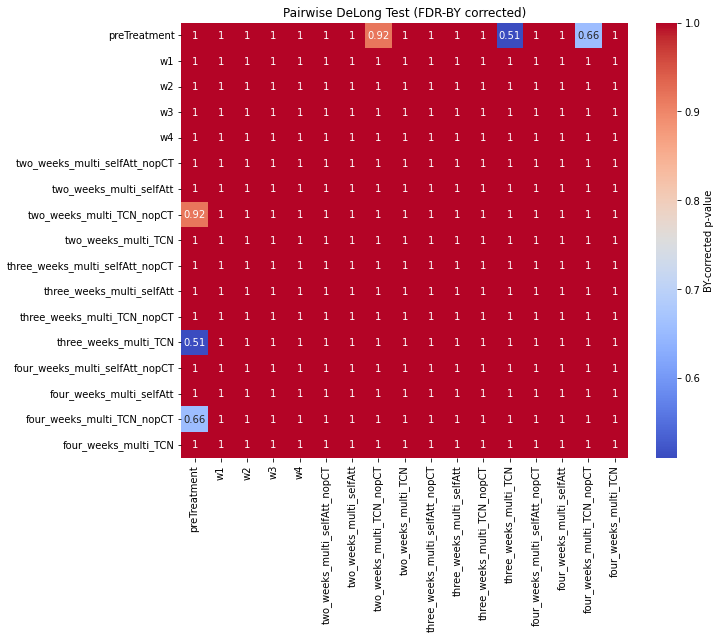

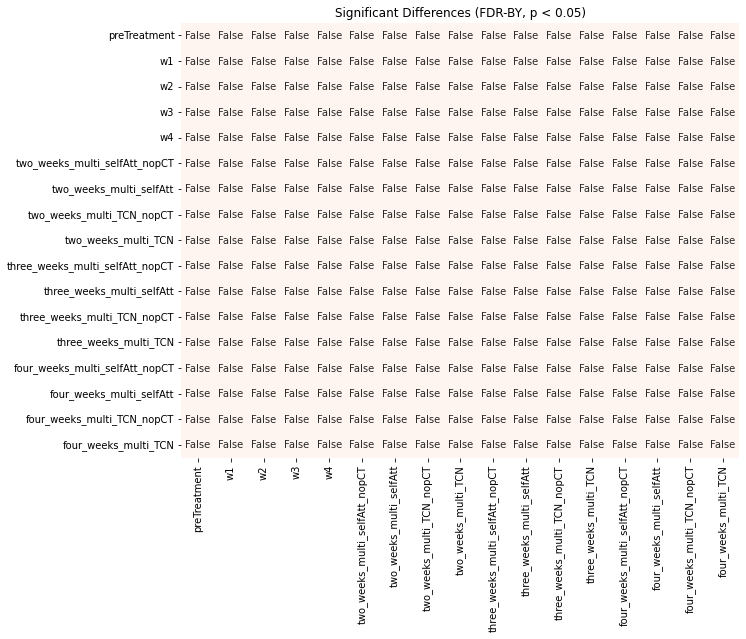

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Function for Benjamini-Yekutieli (BY) correction
def benjamini_yekutieli(pvals):
    pvals = np.array(pvals)
    m = len(pvals)
    cf_m = np.sum(1.0 / np.arange(1, m + 1))  # Correction factor
    pvals_sorted = np.sort(pvals)
    corrected_pvals = np.minimum(1, pvals_sorted * m / cf_m)
    # Reorder corrected p-values to match original order
    idx_sorted = np.argsort(pvals)
    return corrected_pvals[np.argsort(idx_sorted)]

# Step 1: Store results from DeLong test
results = []
model_indices = range(len(pred_probs))
pairs = list(combinations(model_indices, 2))
uncorrected_pvals = []

for i, j in pairs:
    log10_p = delong_roc_test(np.array(lab), pred_probs[i], pred_probs[j])[0][0]
    p = log10_p
    uncorrected_pvals.append(p)
    results.append((nam[i], nam[j], p))

# Step 2: Apply BY correction
pvals_by = benjamini_yekutieli(uncorrected_pvals)

# Step 3: Create result matrix with BY correction
P = 0.05
n = len(nam)
pval_matrix_by = np.ones((n, n))
sig_matrix_by = np.zeros((n, n), dtype=bool)

for ((m1, m2, _), p_by) in zip(results, pvals_by):
    i = nam.index(m1)
    j = nam.index(m2)
    pval_matrix_by[i, j] = p_by
    pval_matrix_by[j, i] = p_by
    sig_matrix_by[i, j] = p_by < P
    sig_matrix_by[j, i] = p_by < P

# Step 4: Convert to DataFrame
df_by = pd.DataFrame(pval_matrix_by, index=nam, columns=nam)

# Step 5: Plot BY-corrected p-value heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_by, annot=True, fmt=".2g", cmap="coolwarm", cbar_kws={'label': 'BY-corrected p-value'})
plt.title("Pairwise DeLong Test (FDR-BY corrected)")
plt.show()

# Step 6: Plot binary heatmap of significance
plt.figure(figsize=(10, 8))
sns.heatmap(sig_matrix_by, annot=True, fmt="", cmap="Reds", xticklabels=nam, yticklabels=nam, cbar=False)
plt.title("Significant Differences (FDR-BY, p < 0.05)")
plt.show()